In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

In [ ]:
# test on a single single choice

In [ ]:
doors = [1,0,0]
random.seed(time.time())
d0 = int((random.random())*(3))
print(d0)

In [ ]:
random.seed(time.time())
dgoat = int(random.random()*2+1)
while dgoat==d0: 
    dgoat = int(random.random()*2+1)
print(dgoat)

In [ ]:
remaining_doors =[]
x = 99 #i name the excluded door to distinguish it from the two still viable doors
for i in range(len(doors)):
    if i!=dgoat: 
        remaining_doors.append(doors[i])
    else: remaining_doors.append(x)
print(remaining_doors)

In [ ]:
result_conservative = d0

In [ ]:
initial_guess = d0
print(d0, dgoat)

In [ ]:
i = d0
while ((i==d0) or (i==dgoat)):
    i = int(random.random()*3)
dswitcher = i
result_switcher = remaining_doors[dswitcher]
print(dswitcher)

In [ ]:
dnewcomer = int(random.random()*3)
while dnewcomer == remaining_doors.index(x):
    dnewcomer = int(random.random()*3)
    print(dnewcomer)
result_newcomer = remaining_doors[dnewcomer]

In [ ]:
#prior choices!!!

In [ ]:
#TOY EXPERIMENT

In [2]:
N = 10000
doors = [1,0,0]

conservative_tally = 0
switcher_tally = 0
newcomer_tally = 0

for i in range(N):
    #player selects a door
    random.seed(time.time())
    d0 = int((random.random())*(3))
    
    #presenter selects a door
    dgoat = int(random.random()*2+1)
    while dgoat==d0: 
        dgoat = int(random.random()*2+1)

    #remaining doors
    remaining_doors =[]
    x=99
    for i in range(len(doors)):
        if i!=dgoat: 
            remaining_doors.append(doors[i])
        else: remaining_doors.append(x)
    
    #conservative conserves
    result_conservative = doors[d0]
    conservative_tally+=result_conservative

    #switcher switches
    i = d0
    while (i==d0 or i==dgoat):
        i = int(random.random()*3)
    dswitcher = i
    result_switcher = remaining_doors[dswitcher]
    switcher_tally+=result_switcher

    #newcomer chooses
    dnewcomer = int(random.random()*3)
    while dnewcomer == remaining_doors.index(x):
        dnewcomer = int(random.random()*3)
    result_newcomer = remaining_doors[dnewcomer]
    newcomer_tally+=result_newcomer

In [3]:
print('conservative: %.4f' % (conservative_tally/N))
print('switcher: %.4f' % (switcher_tally/N))
print('newcomer: %.4f' % (newcomer_tally/N))

conservative: 0.3349
switcher: 0.6651
newcomer: 0.4948


In [4]:
doors = [1,0,0]

conservative_tallies = []
switcher_tallies = []
newcomer_tallies = []

arr_n = np.logspace(2,5.5,20)
arr_n = np.array([int(i) for i in arr_n])


for N in arr_n: 
    conservative_tally = 0
    switcher_tally = 0
    newcomer_tally = 0
    for i in range(N):
        #player selects a door
        random.seed(time.time())
        d0 = int((random.random())*(3))
        
        #presenter selects a door
        dgoat = int(random.random()*2+1)
        while dgoat==d0: 
            dgoat = int(random.random()*2+1)
    
        #remaining doors
        remaining_doors =[]
        x=99
        for i in range(len(doors)):
            if i!=dgoat: 
                remaining_doors.append(doors[i])
            else: remaining_doors.append(x)
        
        #conservative conserves
        result_conservative = doors[d0]
        conservative_tally+=result_conservative
    
        #switcher switches
        i = d0
        while (i==d0 or i==dgoat):
            i = int(random.random()*3)
        dswitcher = i
        result_switcher = remaining_doors[dswitcher]
        switcher_tally+=result_switcher
    
        #newcomer chooses
        dnewcomer = int(random.random()*3)
        while dnewcomer == remaining_doors.index(x):
            dnewcomer = int(random.random()*3)
        result_newcomer = remaining_doors[dnewcomer]
        newcomer_tally+=result_newcomer

        
    conservative_tallies.append(conservative_tally/N)
    switcher_tallies.append(switcher_tally/N)
    newcomer_tallies.append(newcomer_tally/N)
    

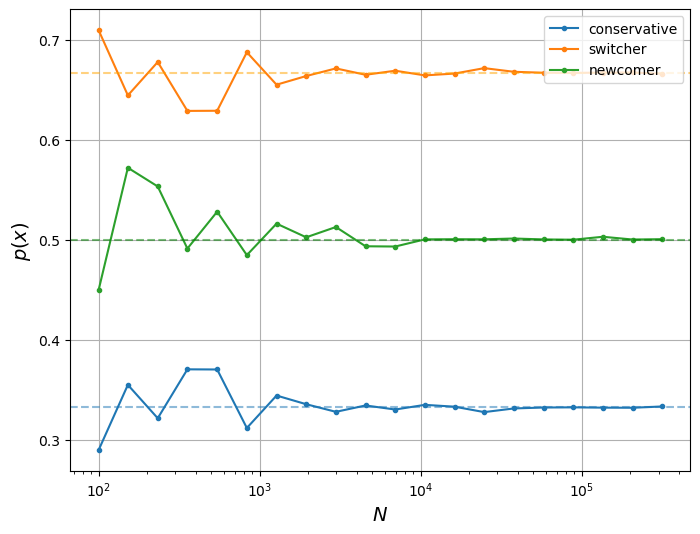

In [7]:
fig,ax = plt.subplots(figsize=(8, 6))
#xgrid = np.linspace(-10, 30, 1000)
plt.plot(arr_n, conservative_tallies,marker='.',label='conservative')
plt.plot(arr_n, switcher_tallies,marker='.',label='switcher')
plt.plot(arr_n, newcomer_tallies,marker='.',label='newcomer')

ax.axhline(1/3, 0, 5000, linestyle='--', alpha=0.5)
ax.axhline(2/3, 0, 5000, linestyle='--', color='orange', alpha=0.5)
ax.axhline(1/2, 0, 5000, linestyle='--', color='green', alpha=0.5)

ax.set_xscale('log')
ax.set_ylabel('$p(x)$',fontsize=14)
ax.legend(loc='upper right')

ax.set_xlabel('$N$',fontsize=14)

plt.grid()

plt.show()

In [6]:
print('conservative: %.4f' % np.mean(conservative_tallies))
print('switcher: %.4f' % np.mean(switcher_tallies))
print('newcomer: %.4f' % np.mean(newcomer_tallies))

conservative: 0.3344
switcher: 0.6656
newcomer: 0.5055
